# HowReliable? â€” NHTSA ODI Complaints EDA

Phase 2A reproducible exploration of the official complaints-received 2020â€“2024 artifact. This notebook reports source coverage and quality only. Raw complaint volume is not a reliability rate, and no cleaning, deduplication, feature engineering, label design, or model training occurs here.

## 1. Setup and reproducible input

In [1]:
from __future__ import annotations

import json
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from howreliable.data.ingestion.nhtsa_complaints import (
    SOURCE_COLUMNS,
    NhtsaComplaintRecord,
)
from howreliable.data.mapping import EventMappingError, map_nhtsa_complaint

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data/interim/nhtsa/complaints/complaints-2020-2024.jsonl"
PROVENANCE_PATH = DATA_PATH.with_suffix(f"{DATA_PATH.suffix}.provenance.json")
assert DATA_PATH.exists(), f"Missing Phase 1B output: {DATA_PATH}"
assert PROVENANCE_PATH.exists(), f"Missing provenance: {PROVENANCE_PATH}"
print({"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__})

{'python': '3.12.3', 'pandas': '2.3.2', 'numpy': '2.3.2'}


In [2]:
provenance = json.loads(PROVENANCE_PATH.read_text(encoding="utf-8"))
complaints = pd.read_json(DATA_PATH, lines=True, dtype=False)
assert list(complaints.columns) == list(SOURCE_COLUMNS)
assert len(complaints) == provenance["record_count"]
print(
    {
        "shape": complaints.shape,
        "memory_mib": round(complaints.memory_usage(deep=True).sum() / 2**20, 2),
        "source_sha256": provenance["source_artifact_sha256"],
        "complete_artifact": provenance["complete_artifact"],
    }
)

{'shape': (418884, 51), 'memory_mib': np.float64(1111.5), 'source_sha256': '7ce0ae08713024ce3d5a078c99ef9ddebf62a5ca2e0aee81568d98ae8d44750d', 'complete_artifact': True}


## 2. Dataset overview and identifier behavior

In [3]:
overview = pd.Series(
    {
        "records": len(complaints),
        "columns": complaints.shape[1],
        "memory_mib": complaints.memory_usage(deep=True).sum() / 2**20,
        "unique_cmplid": complaints["CMPLID"].nunique(dropna=True),
        "duplicated_cmplid_rows": complaints.duplicated("CMPLID", keep=False).sum(),
        "unique_odino": complaints["ODINO"].nunique(dropna=True),
        "rows_with_repeated_odino": complaints.duplicated("ODINO", keep=False).sum(),
        "exact_duplicate_rows": complaints.duplicated(keep=False).sum(),
    }
)
display(overview.to_frame("value"))
display(
    complaints["PROD_TYPE"]
    .value_counts(dropna=False)
    .rename_axis("product_type")
    .to_frame("records")
)

,value
records,418884.000000
columns,51.000000
memory_mib,1111.503922
unique_cmplid,418884.000000
duplicated_cmplid_rows,0.000000
unique_odino,291999.000000
rows_with_repeated_odino,217232.000000
exact_duplicate_rows,0.000000


,records
product_type,
V,413239
T,3091
E,1696
C,851
NaN,7


## 3. Missing values

,missing_count,missing_percent
MAKETXT,7,0.002
MODELTXT,7,0.002
YEARTXT,7,0.002
MILES,268824,64.176
FAILDATE,0,0.000
LDATE,0,0.000
COMPDESC,2,0.000
INJURED,0,0.000
DEATHS,0,0.000
CRASH,0,0.000


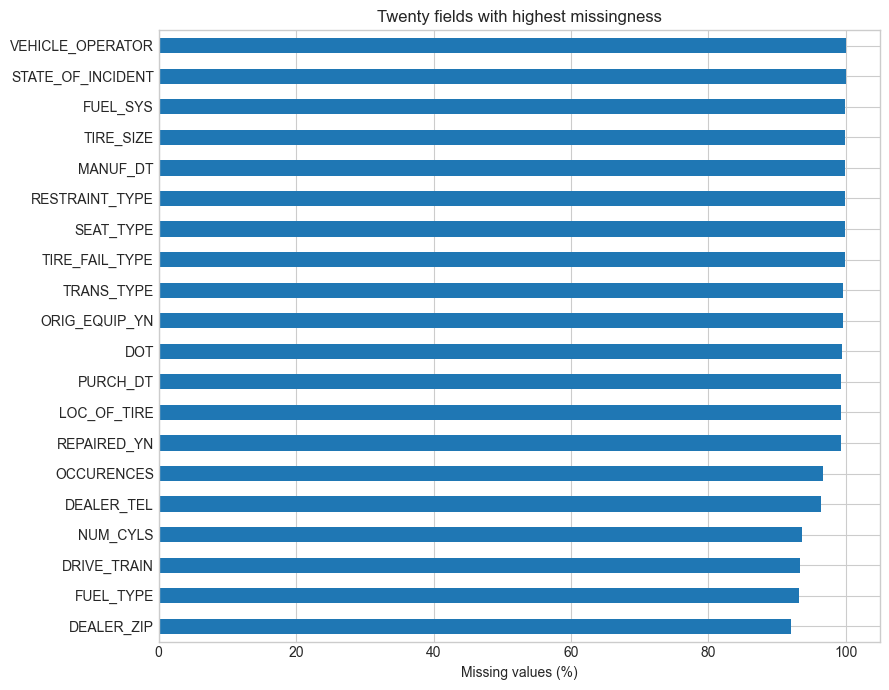

In [4]:
missingness = pd.DataFrame(
    {
        "missing_count": complaints.isna().sum(),
        "missing_percent": complaints.isna().mean().mul(100),
    }
).sort_values(["missing_percent", "missing_count"], ascending=False)
key_fields = [
    "MAKETXT",
    "MODELTXT",
    "YEARTXT",
    "MILES",
    "FAILDATE",
    "LDATE",
    "COMPDESC",
    "INJURED",
    "DEATHS",
    "CRASH",
    "FIRE",
    "TRANS_TYPE",
    "DRIVE_TRAIN",
    "CDESCR",
]
display(missingness.loc[key_fields].round(3))
ax = (
    missingness.head(20)
    .sort_values("missing_percent")["missing_percent"]
    .plot.barh(figsize=(9, 7), title="Twenty fields with highest missingness")
)
ax.set_xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

## 4. Vehicle coverage

Counts below describe representation in the complaint corpus. They do **not** compare reliability because vehicle population and exposure are unavailable.

,value
vehicle_product_rows,413239
non_vehicle_rows,5645
unique_makes,359
unique_models,2505
unique_make_model_year,10747


,complaint_records
make,
FORD,72081
CHEVROLET,36753
HONDA,32100
HYUNDAI,26752
JEEP,26193
KIA,23562
TOYOTA,22096
NISSAN,18383
TESLA,16606


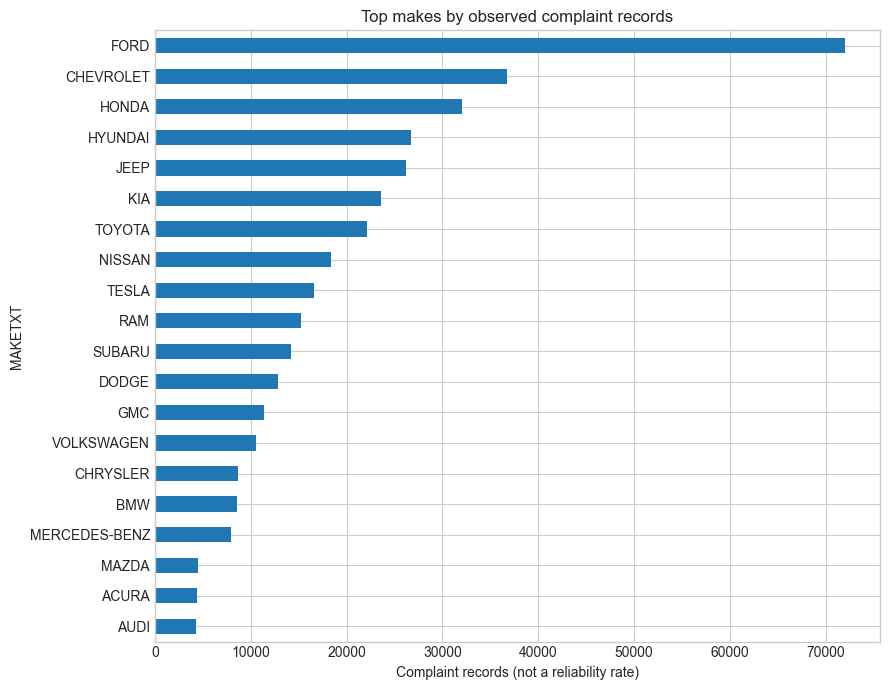

,records
YEARTXT,
1987,16
1988,18
1989,16
1990,23
1991,37
1992,20
1993,48
1994,75
1995,81


In [5]:
vehicle_rows = complaints["PROD_TYPE"].eq("V")
vehicle_coverage = pd.Series(
    {
        "vehicle_product_rows": int(vehicle_rows.sum()),
        "non_vehicle_rows": int((~vehicle_rows).sum()),
        "unique_makes": complaints.loc[vehicle_rows, "MAKETXT"].nunique(dropna=True),
        "unique_models": complaints.loc[vehicle_rows, "MODELTXT"].nunique(dropna=True),
        "unique_make_model_year": complaints.loc[vehicle_rows, ["MAKETXT", "MODELTXT", "YEARTXT"]]
        .drop_duplicates()
        .shape[0],
    }
)
display(vehicle_coverage.to_frame("value"))
top_makes = complaints.loc[vehicle_rows, "MAKETXT"].value_counts().head(20)
display(top_makes.rename_axis("make").to_frame("complaint_records"))
ax = top_makes.sort_values().plot.barh(
    figsize=(9, 7), title="Top makes by observed complaint records"
)
ax.set_xlabel("Complaint records (not a reliability rate)")
plt.tight_layout()
plt.show()
display(
    complaints.loc[vehicle_rows, "YEARTXT"]
    .value_counts(dropna=False)
    .sort_index()
    .tail(40)
    .to_frame("records")
)

## 5. Mileage diagnostics (no correction or removal)

,value
available,150060
missing,268824
malformed_present,0
zero,4552
over_500k,337
over_1m,156
maximum,9848609


,mileage
count,150060.0
mean,76906.162742
std,108757.308657
min,0.0
1%,0.0
25%,27000.0
50%,68000.0
75%,110000.0
95%,178986.0
99%,240000.0


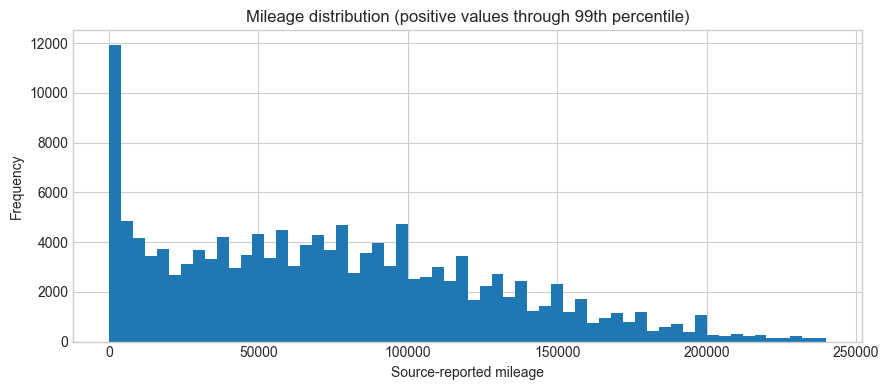

In [6]:
mileage_text = complaints["MILES"].astype("string")
mileage_present = mileage_text.notna()
mileage_format_valid = mileage_text.str.fullmatch(r"[0-9]+", na=False)
mileage_numeric = pd.to_numeric(mileage_text.where(mileage_format_valid), errors="coerce")
mileage_summary = pd.Series(
    {
        "available": int(mileage_present.sum()),
        "missing": int((~mileage_present).sum()),
        "malformed_present": int((mileage_present & ~mileage_format_valid).sum()),
        "zero": int(mileage_numeric.eq(0).sum()),
        "over_500k": int(mileage_numeric.gt(500_000).sum()),
        "over_1m": int(mileage_numeric.gt(1_000_000).sum()),
        "maximum": mileage_numeric.max(),
    }
)
display(mileage_summary.to_frame("value"))
display(
    mileage_numeric.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).to_frame(
        "mileage"
    )
)
plot_ceiling = mileage_numeric.quantile(0.99)
ax = mileage_numeric[mileage_numeric.between(1, plot_ceiling)].plot.hist(
    bins=60, figsize=(9, 4), title="Mileage distribution (positive values through 99th percentile)"
)
ax.set_xlabel("Source-reported mileage")
plt.tight_layout()
plt.show()

## 6. Date availability, ranges, and report delay

,value
occurrence_available,418884
occurrence_missing,0
occurrence_malformed_present,0
occurrence_min,1917-01-01 00:00:00
occurrence_max,2024-12-31 00:00:00
report_available,418884
report_missing,0
report_malformed_present,0
report_min,2020-01-01 00:00:00
report_max,2024-12-31 00:00:00


,delay_days
count,418884.000000
mean,133.028731
std,514.762259
min,-44.000000
1%,0.000000
25%,1.000000
50%,11.000000
75%,74.000000
95%,674.000000
99%,1836.170000


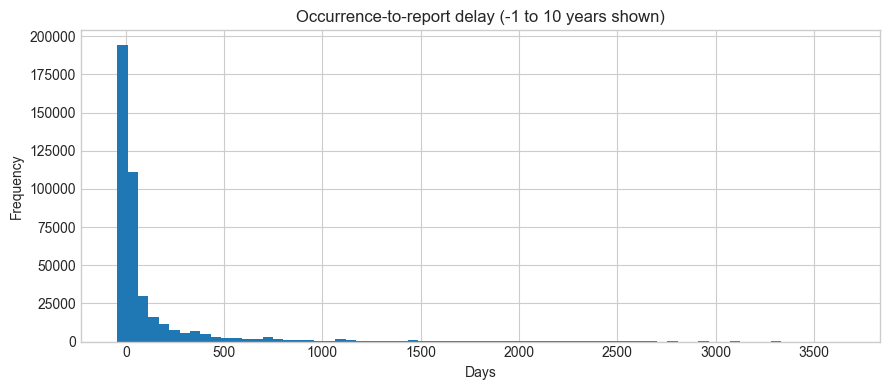

In [7]:
occurrence_dates = pd.to_datetime(complaints["FAILDATE"], format="%Y%m%d", errors="coerce")
report_dates = pd.to_datetime(complaints["LDATE"], format="%Y%m%d", errors="coerce")
occurrence_present = complaints["FAILDATE"].notna()
report_present = complaints["LDATE"].notna()
report_delay_days = (report_dates - occurrence_dates).dt.days
date_summary = pd.Series(
    {
        "occurrence_available": int(occurrence_dates.notna().sum()),
        "occurrence_missing": int((~occurrence_present).sum()),
        "occurrence_malformed_present": int((occurrence_present & occurrence_dates.isna()).sum()),
        "occurrence_min": occurrence_dates.min(),
        "occurrence_max": occurrence_dates.max(),
        "report_available": int(report_dates.notna().sum()),
        "report_missing": int((~report_present).sum()),
        "report_malformed_present": int((report_present & report_dates.isna()).sum()),
        "report_min": report_dates.min(),
        "report_max": report_dates.max(),
        "paired_valid_dates": int(report_delay_days.notna().sum()),
        "negative_delays": int(report_delay_days.lt(0).sum()),
        "delays_over_10_years": int(report_delay_days.gt(3652).sum()),
    }
)
display(date_summary.to_frame("value"))
display(
    report_delay_days.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(
        "delay_days"
    )
)
ax = report_delay_days[report_delay_days.between(-365, 3652)].plot.hist(
    bins=70, figsize=(9, 4), title="Occurrence-to-report delay (-1 to 10 years shown)"
)
ax.set_xlabel("Days")
plt.tight_layout()
plt.show()

## 7. Full ReliabilityEvent mapping diagnostic

In [8]:
mapped = np.zeros(len(complaints), dtype=bool)
canonical_components = np.full(len(complaints), None, dtype=object)
canonical_severity = np.full(len(complaints), None, dtype=object)
rejection_reason = np.full(len(complaints), None, dtype=object)

for position, values in enumerate(
    complaints.loc[:, SOURCE_COLUMNS].itertuples(index=False, name=None)
):
    source_values = tuple(None if pd.isna(value) else str(value) for value in values)
    record = NhtsaComplaintRecord(source_values)
    try:
        event = map_nhtsa_complaint(record)
    except EventMappingError as error:
        rejection_reason[position] = error.reason.value
    else:
        mapped[position] = True
        canonical_components[position] = event.component.value
        canonical_severity[position] = event.severity.value

mapping = pd.DataFrame(
    {
        "mapped": mapped,
        "component": canonical_components,
        "severity": canonical_severity,
        "rejection_reason": rejection_reason,
    },
    index=complaints.index,
)
mapping_summary = pd.Series(
    {
        "mapped": int(mapping["mapped"].sum()),
        "rejected": int((~mapping["mapped"]).sum()),
        "mapping_success_percent": mapping["mapped"].mean() * 100,
    }
)
display(mapping_summary.to_frame("value"))
display(mapping.loc[~mapping["mapped"], "rejection_reason"].value_counts().to_frame("records"))

,value
mapped,412866.000000
rejected,6018.000000
mapping_success_percent,98.563325


,records
rejection_reason,
unsupported_product_type,5645
invalid_model_year,373


## 8. Canonical and original component coverage

,records,percent_of_mapped
component,,
other,150823,36.531
engine,65591,15.887
electrical,51087,12.374
brakes,30336,7.348
steering,29379,7.116
airbags_restraints,24024,5.819
fuel_system,23720,5.745
body,16325,3.954
suspension,12033,2.915


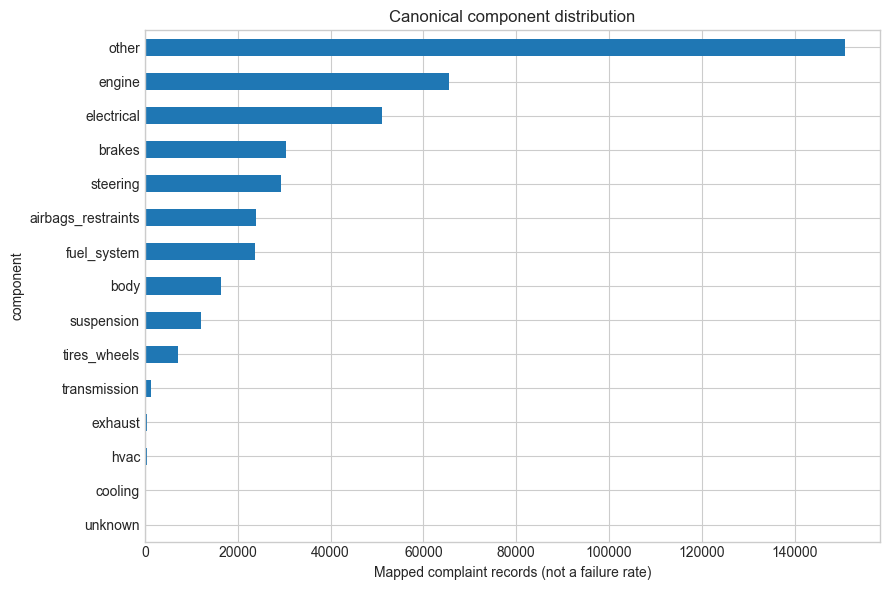

,records
COMPDESC,
ENGINE,59690
ELECTRICAL SYSTEM,48883
UNKNOWN OR OTHER,40822
POWER TRAIN,37976
STEERING,28858
SERVICE BRAKES,25307
AIR BAGS,19224
FUEL/PROPULSION SYSTEM,18656
STRUCTURE:BODY,12794


,records_mapping_to_other
original_component,
UNKNOWN OR OTHER,40822
POWER TRAIN,37976
VEHICLE SPEED CONTROL,10996
VISIBILITY/WIPER,9467
EXTERIOR LIGHTING,9374
FORWARD COLLISION AVOIDANCE: AUTOMATIC EMERGENCY BRAKING,8147
FORWARD COLLISION AVOIDANCE: ADAPTIVE CRUISE CONTROL,5052
FORWARD COLLISION AVOIDANCE: WARNINGS,4176
SEATS,3987


,count,median,mean,max
component,,,,
airbags_restraints,8894,74000.0,83318.4,9848609
body,6594,65000.0,77106.2,1876543
brakes,10802,63000.0,75976.7,9000000
cooling,148,93500.0,94185.3,385000
electrical,17478,58104.5,70207.4,9800000
engine,26962,82000.0,86397.4,9000000
exhaust,403,88520.0,88469.2,257600
fuel_system,8732,70000.0,78931.2,7156000
hvac,235,57000.0,66490.7,235000


In [9]:
component_counts = mapping.loc[mapping["mapped"], "component"].value_counts()
component_distribution = pd.DataFrame(
    {
        "records": component_counts,
        "percent_of_mapped": component_counts.div(mapping["mapped"].sum()).mul(100),
    }
)
display(component_distribution.round(3))
ax = component_counts.sort_values().plot.barh(
    figsize=(9, 6), title="Canonical component distribution"
)
ax.set_xlabel("Mapped complaint records (not a failure rate)")
plt.tight_layout()
plt.show()
display(
    complaints.loc[mapping["mapped"], "COMPDESC"]
    .value_counts(dropna=False)
    .head(25)
    .to_frame("records")
)
other_mask = mapping["mapped"] & mapping["component"].eq("other")
other_original = complaints.loc[other_mask, "COMPDESC"].value_counts(dropna=False).head(30)
display(other_original.rename_axis("original_component").to_frame("records_mapping_to_other"))
component_mileage = pd.DataFrame({"component": mapping["component"], "mileage": mileage_numeric})
display(
    component_mileage.groupby("component")["mileage"]
    .agg(["count", "median", "mean", "max"])
    .round(1)
)

## 9. Severity evidence and imbalance

,records,percent_of_mapped
severity,,
low,383669,92.9282
moderate,17754,4.3002
high,11051,2.6767
critical,392,0.0949


records
CRASH FIRE INJURED DEATHS         
N     N    0       0        389321
Y     N    0       0         10731
N     Y    0       0          6949
Y     N    1       0          5355
N     N    1       0          2581
Y     N    2       0          1636
           3       0           366
N     Y    1       0           353
Y     Y    0       0           292
N     N    2       0           278
Y     Y    1       0           145
      N    4       0           120
           0       1           100
           1       1            73
N     Y    2       0            63
      N    3       0            48
Y     Y    2       0            47
N     N    4       0            35
Y     N    6       0            33
           5       0            29

,records
crash_Y,19125
fire_Y,8015
injury_count_positive,11417
death_count_positive,411
unknown_severity,0


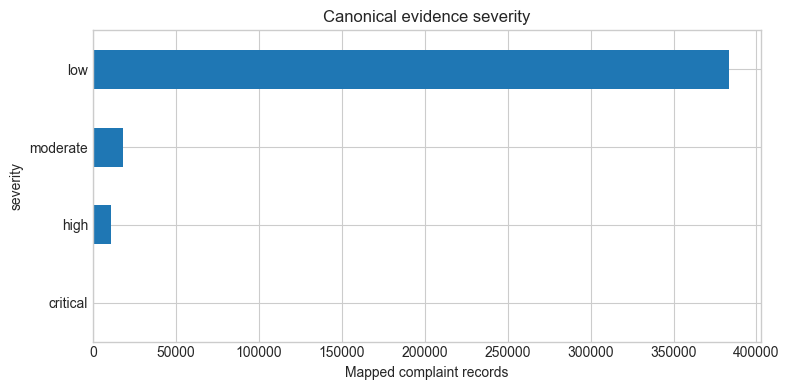

In [10]:
severity_counts = mapping.loc[mapping["mapped"], "severity"].value_counts()
severity_distribution = pd.DataFrame(
    {
        "records": severity_counts,
        "percent_of_mapped": severity_counts.div(mapping["mapped"].sum()).mul(100),
    }
)
display(severity_distribution.round(4))
display(
    complaints.groupby(["CRASH", "FIRE", "INJURED", "DEATHS"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(20)
    .to_frame("records")
)
evidence_summary = pd.Series(
    {
        "crash_Y": complaints["CRASH"].eq("Y").sum(),
        "fire_Y": complaints["FIRE"].eq("Y").sum(),
        "injury_count_positive": pd.to_numeric(complaints["INJURED"], errors="coerce").gt(0).sum(),
        "death_count_positive": pd.to_numeric(complaints["DEATHS"], errors="coerce").gt(0).sum(),
        "unknown_severity": mapping["severity"].eq("unknown").sum(),
    }
)
display(evidence_summary.to_frame("records"))
ax = severity_counts.sort_values().plot.barh(figsize=(8, 4), title="Canonical evidence severity")
ax.set_xlabel("Mapped complaint records")
plt.tight_layout()
plt.show()

## 10. Narrative structure only (no NLP)

In [11]:
narrative_lengths = complaints["CDESCR"].astype("string").str.len()
narrative_summary = pd.Series(
    {
        "missing": narrative_lengths.isna().sum(),
        "available": narrative_lengths.notna().sum(),
        "length_zero": narrative_lengths.eq(0).sum(),
        "length_1_to_10": narrative_lengths.between(1, 10).sum(),
        "over_documented_2048": narrative_lengths.gt(2048).sum(),
        "maximum_length": narrative_lengths.max(),
    }
)
display(narrative_summary.to_frame("value"))
display(
    narrative_lengths.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(
        "characters"
    )
)

,value
missing,0
available,418884
length_zero,0
length_1_to_10,908
over_documented_2048,441
maximum_length,2105


,characters
count,418884.0
mean,591.738419
std,439.438581
min,1.0
1%,30.0
25%,271.0
50%,499.0
75%,776.0
95%,1564.85
99%,1997.0


## 11. Repeated references and potential duplicates (retained)

In [12]:
odino_sizes = complaints.dropna(subset=["ODINO"]).groupby("ODINO").size()
components_per_odino = (
    complaints.dropna(subset=["ODINO"]).groupby("ODINO")["COMPDESC"].nunique(dropna=True)
)
combination_columns = ["MAKETXT", "MODELTXT", "YEARTXT", "COMPDESC"]
combination_sizes = (
    complaints.groupby(combination_columns, dropna=False).size().sort_values(ascending=False)
)
duplicate_summary = pd.Series(
    {
        "exact_duplicate_rows_including_all_copies": complaints.duplicated(keep=False).sum(),
        "duplicate_cmplid_rows_including_all_copies": complaints.duplicated(
            "CMPLID", keep=False
        ).sum(),
        "odino_values_repeated": odino_sizes.gt(1).sum(),
        "rows_under_repeated_odino": odino_sizes[odino_sizes.gt(1)].sum(),
        "maximum_rows_for_one_odino": odino_sizes.max(),
        "odino_with_multiple_nonmissing_components": components_per_odino.gt(1).sum(),
        "repeated_vehicle_year_component_groups": combination_sizes.gt(1).sum(),
    }
)
display(duplicate_summary.to_frame("value"))
display(combination_sizes.head(20).to_frame("records"))

,value
exact_duplicate_rows_including_all_copies,0
duplicate_cmplid_rows_including_all_copies,0
odino_values_repeated,90347
rows_under_repeated_odino,217232
maximum_rows_for_one_odino,9
odino_with_multiple_nonmissing_components,88185
repeated_vehicle_year_component_groups,37208


records
MAKETXT MODELTXT YEARTXT COMPDESC               
RAM     2500     2018    SERVICE BRAKES     1565
FORD    ESCAPE   2017    ENGINE              894
HONDA   CIVIC    2022    STEERING            687
FORD    F-250 SD 2019    STEERING            620
        ESCAPE   2018    ENGINE              587
        F-250 SD 2019    SUSPENSION          541
KIA     SORENTO  2016    ENGINE              540
FORD    F-150    2013    POWER TRAIN         498
        EDGE     2017    ENGINE              483
        FUSION   2012    STEERING            473
        ESCAPE   2013    ENGINE              454
HYUNDAI SANTA FE 2017    ENGINE              452
FORD    ESCAPE   2020    STRUCTURE:BODY      448
KIA     SOUL     2015    ENGINE              448
HONDA   PILOT    2016    ENGINE              427
RAM     3500     2018    SERVICE BRAKES      423
FORD    F-150    2018    POWER TRAIN         417
        FOCUS    2014    POWER TRAIN         403
        FUSION   2011    STEERING            403
KIA     SOUL     2016    ENGINE              402

## 12. Temporal coverage and model-year lag

,complaint_records
LDATE,
2020,83356
2021,69128
2022,76628
2023,91757
2024,98015


,report_year_minus_model_year
count,412953.000000
mean,6.101791
std,4.542353
min,-1.000000
1%,0.000000
25%,3.000000
50%,6.000000
75%,8.000000
95%,15.000000
99%,20.000000


{'negative_model_year_lag': 2241, 'lag_over_30_years': 182}


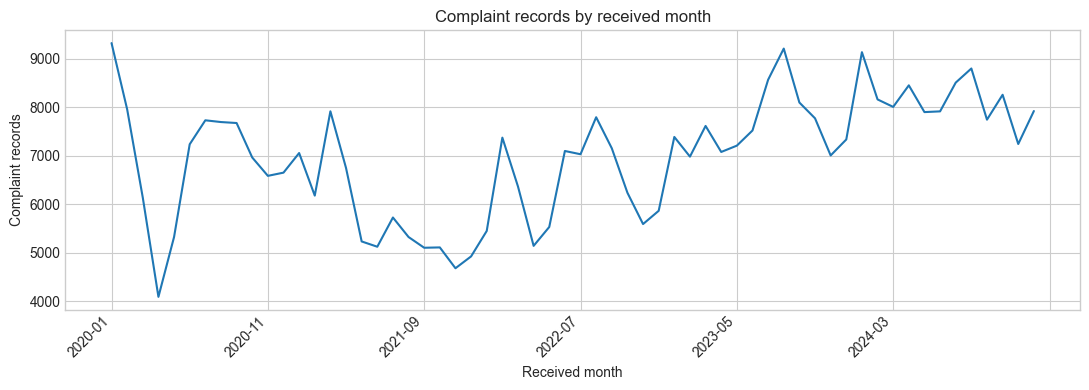

In [13]:
received_year = report_dates.dt.year
received_month = report_dates.dt.to_period("M").astype("string")
model_year_numeric = pd.to_numeric(complaints["YEARTXT"], errors="coerce").where(
    lambda x: x.ne(9999)
)
model_year_lag = received_year - model_year_numeric
display(received_year.value_counts(dropna=False).sort_index().to_frame("complaint_records"))
display(
    model_year_lag.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(
        "report_year_minus_model_year"
    )
)
print(
    {
        "negative_model_year_lag": int(model_year_lag.lt(0).sum()),
        "lag_over_30_years": int(model_year_lag.gt(30).sum()),
    }
)
monthly_counts = received_month.value_counts().sort_index()
ax = monthly_counts.plot(figsize=(11, 4), title="Complaint records by received month")
ax.set_ylabel("Complaint records")
ax.set_xlabel("Received month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Representation imbalance and reproducible headline facts

In [14]:
headline = {
    "records": len(complaints),
    "memory_mib": round(float(complaints.memory_usage(deep=True).sum() / 2**20), 2),
    "mapped": int(mapping["mapped"].sum()),
    "rejected": int((~mapping["mapped"]).sum()),
    "mapping_success_percent": round(float(mapping["mapped"].mean() * 100), 4),
    "component_other_percent": round(
        float(mapping["component"].eq("other").sum() / mapping["mapped"].sum() * 100), 4
    ),
    "component_unknown_percent": round(
        float(mapping["component"].eq("unknown").sum() / mapping["mapped"].sum() * 100), 4
    ),
    "severity_unknown_percent": round(
        float(mapping["severity"].eq("unknown").sum() / mapping["mapped"].sum() * 100), 4
    ),
    "top_make_share_percent": round(float(top_makes.iloc[0] / vehicle_rows.sum() * 100), 4),
    "top_component_share_percent": round(
        float(component_counts.iloc[0] / mapping["mapped"].sum() * 100), 4
    ),
    "top_severity_share_percent": round(
        float(severity_counts.iloc[0] / mapping["mapped"].sum() * 100), 4
    ),
}
display(pd.Series(headline).to_frame("value"))
print(json.dumps(headline, indent=2))

,value
records,418884.0000
memory_mib,1147.5800
mapped,412866.0000
rejected,6018.0000
mapping_success_percent,98.5633
component_other_percent,36.5307
component_unknown_percent,0.0002
severity_unknown_percent,0.0000
top_make_share_percent,17.4429
top_component_share_percent,36.5307


{
  "records": 418884,
  "memory_mib": 1147.58,
  "mapped": 412866,
  "rejected": 6018,
  "mapping_success_percent": 98.5633,
  "component_other_percent": 36.5307,
  "component_unknown_percent": 0.0002,
  "severity_unknown_percent": 0.0,
  "top_make_share_percent": 17.4429,
  "top_component_share_percent": 36.5307,
  "top_severity_share_percent": 92.9282
}


## Interpretation guardrails and Phase 2B candidates

Observed counts describe this complaint corpus only. Future Phase 2B work may investigate malformed dates/mileage, zero-value ambiguity, encoding artifacts, coarse `OTHER` components, source-reference multiplicity, and vehicle-name consistency. This notebook does not decide how to clean any of them. Population normalization, target definition, and reliability conclusions remain out of scope.